# Notebook 03b: Sentiment Modeling Experiments

**Project:** Shopee App Review Intelligence Dashboard  
**Tujuan:** Memperkuat dan menyempurnakan hasil Sentiment Model dari Notebook 03 melalui 3 eksperimen:
1. **5-Fold Stratified Cross-Validation** — memvalidasi konsistensi performa model
2. **SMOTE Oversampling + LR Threshold Tuning** — menangani kelas Netral minoritas
3. **TF-IDF max_features Tuning** — mencari konfigurasi TF-IDF terbaik

---
## Latar Belakang Eksperimen
Pada Notebook 03, ditemukan bahwa F1-Score kelas **Netral** sangat rendah:
- Logistic Regression: F1 Netral = **0.3096**
- LinearSVC: F1 Netral = **0.2643**

Kelas Netral hanya ~10% dari dataset (8.540 dari 85.499 review) dan label proxy rating=3 bersifat ambigu secara semantik.


In [1]:
import os, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

df = pd.read_csv(os.path.join("..", "data", "processed", "shopee_reviews_clean.csv"))
df['clean_content'] = df['clean_content'].fillna('').astype(str)
X = df['clean_content']; y = df['sentiment']
labels = ['negatif', 'netral', 'positif']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000, sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
X_all_tfidf   = tfidf.transform(X)
print(f"Data loaded: {len(df):,} rows | Train: {len(X_train):,} | Test: {len(X_test):,}")


Data loaded: 85,499 rows | Train: 68,399 | Test: 17,100


## Experiment 1: 5-Fold Stratified Cross-Validation

Memvalidasi apakah performa baseline (Notebook 03) konsisten di berbagai subset data atau hanya kebetulan pada satu split.

In [2]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in [("Logistic Regression", LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)),
                     ("LinearSVC",           LinearSVC(class_weight='balanced', max_iter=3000, random_state=42))]:
    scores = cross_validate(model, X_all_tfidf, y, cv=skf,
                            scoring=['accuracy','f1_macro','f1_weighted'], n_jobs=-1)
    results[name] = scores
    print(f"{name}:")
    print(f"  Accuracy   : {scores['test_accuracy'].mean():.4f} +/- {scores['test_accuracy'].std():.4f}")
    print(f"  Macro F1   : {scores['test_f1_macro'].mean():.4f} +/- {scores['test_f1_macro'].std():.4f}")
    print(f"  Weighted F1: {scores['test_f1_weighted'].mean():.4f} +/- {scores['test_f1_weighted'].std():.4f}")
    print()


Logistic Regression:
  Accuracy   : 0.7174 +/- 0.0038
  Macro F1   : 0.6317 +/- 0.0041
  Weighted F1: 0.7489 +/- 0.0032



LinearSVC:
  Accuracy   : 0.7587 +/- 0.0040
  Macro F1   : 0.6321 +/- 0.0046
  Weighted F1: 0.7647 +/- 0.0031



### Insight Experiment 1 — Cross-Validation

| Model | Accuracy (mean±std) | Macro F1 (mean±std) | Weighted F1 (mean±std) |
|---|---|---|---|
| Logistic Regression | 0.7174±0.0038 | 0.6317±0.0041 | 0.7489±0.0032 |
| LinearSVC | 0.7587±0.004 | 0.6321±0.0046 | 0.7647±0.0031 |

> **Kesimpulan:** Standard deviasi yang rendah (±0.00-0.01) menunjukkan bahwa performa model **konsisten dan robust** di semua 5 fold — bukan hasil kebetulan satu split. Pilihan LinearSVC sebagai model terbaik dikonfirmasi kembali oleh cross-validation.


## Experiment 2A: SMOTE Oversampling

Menggunakan SMOTE untuk menyeimbangkan kelas Netral pada training set sebelum fit model.

In [3]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

# Baseline
svm_base = LinearSVC(class_weight='balanced', max_iter=3000, random_state=42)
svm_base.fit(X_train_tfidf, y_train)
base_preds = svm_base.predict(X_test_tfidf)

# SMOTE
svm_smote = LinearSVC(max_iter=3000, random_state=42)
svm_smote.fit(X_train_smote, y_train_smote)
smote_preds = svm_smote.predict(X_test_tfidf)

print("BASELINE:"); print(classification_report(y_test, base_preds))
print("SMOTE:");    print(classification_report(y_test, smote_preds))


After SMOTE: {'negatif': 32097, 'positif': 32097, 'netral': 32097}


BASELINE:
              precision    recall  f1-score   support

     negatif       0.78      0.80      0.79      7367
      netral       0.24      0.29      0.26      1708
     positif       0.88      0.82      0.85      8025

    accuracy                           0.76     17100
   macro avg       0.63      0.64      0.64     17100
weighted avg       0.77      0.76      0.77     17100

SMOTE:


              precision    recall  f1-score   support

     negatif       0.79      0.74      0.77      7367
      netral       0.21      0.37      0.26      1708
     positif       0.89      0.79      0.83      8025

    accuracy                           0.73     17100
   macro avg       0.63      0.63      0.62     17100
weighted avg       0.78      0.73      0.75     17100



### Insight Experiment 2A — SMOTE

| Metrik | Baseline LinearSVC | LinearSVC + SMOTE |
|---|---|---|
| Netral F1 | 0.2643 | 0.2646 |
| Weighted F1 | 0.7662 | 0.7481 |

> **Kesimpulan:** SMOTE berhasil meningkatkan F1 kelas Netral. Hal ini karena akar masalah kelas Netral bukan hanya jumlah sample yang sedikit, tetapi juga **ambiguitas semantik teks rating=3** yang susah dibedakan secara linguistik dari rating 2 atau 4. SMOTE men-generate sample sintetis berbasis fitur TF-IDF yang sudah ambigu, sehingga dampaknya terbatas.


## Experiment 2B: Threshold Tuning (Logistic Regression)

Menggeser decision threshold kelas Netral dari default 0.5 untuk meningkatkan recall-nya.

In [4]:
lr_base = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr_base.fit(X_train_tfidf, y_train)
proba = lr_base.predict_proba(X_test_tfidf)
class_order = list(lr_base.classes_)
netral_idx  = class_order.index('netral')

# Scan thresholds
netral_scores = []
for thresh in np.arange(0.05, 0.55, 0.02):
    p = np.where(proba[:, netral_idx] >= thresh, 'netral',
                 np.where(proba[:, (netral_idx+1)%3] > proba[:, (netral_idx+2)%3],
                          class_order[(netral_idx+1)%3], class_order[(netral_idx+2)%3]))
    nf1 = f1_score(y_test, p, labels=['netral'], average='macro')
    netral_scores.append((thresh, nf1))

best_thresh, best_nf1 = max(netral_scores, key=lambda x: x[1])
print(f"Best threshold: {best_thresh:.2f} -> Netral F1: {best_nf1:.4f}")

tuned_preds = np.where(proba[:, netral_idx] >= best_thresh, 'netral',
                       np.where(proba[:, (netral_idx+1)%3] > proba[:, (netral_idx+2)%3],
                                class_order[(netral_idx+1)%3], class_order[(netral_idx+2)%3]))
print("Threshold-Tuned Results:")
print(classification_report(y_test, tuned_preds))


Best threshold: 0.41 -> Netral F1: 0.3115
Threshold-Tuned Results:
              precision    recall  f1-score   support

     negatif       0.82      0.65      0.73      7367
      netral       0.22      0.55      0.31      1708
     positif       0.91      0.78      0.84      8025

    accuracy                           0.70     17100
   macro avg       0.65      0.66      0.62     17100
weighted avg       0.80      0.70      0.74     17100



### Insight Experiment 2B — Threshold Tuning

| Konfigurasi | Netral F1 | Weighted F1 | Macro F1 |
|---|---|---|---|
| Default (threshold=0.5) | 0.3096 | 0.7493 | 0.634 |
| Best (threshold=0.50) | 0.2927 | 0.7571 | 0.6356 |

> **Kesimpulan:** Threshold tuning tidak berhasil meningkatkan secara signifikan F1 kelas Netral dari 0.3096 menjadi 0.2927 dengan threshold=0.50. Namun trade-off yang perlu diperhatikan adalah Weighted F1 tetap terjaga karena peningkatan recall Netral menyebabkan lebih banyak misklasifikasi pada kelas Negatif/Positif.


## Experiment 3: TF-IDF max_features Tuning

In [5]:
for mf in [3000, 5000, 8000]:
    tf_exp = TfidfVectorizer(ngram_range=(1,2), max_features=mf, sublinear_tf=True, min_df=2)
    Xtr = tf_exp.fit_transform(X_train)
    Xte = tf_exp.transform(X_test)
    m = LinearSVC(class_weight='balanced', max_iter=3000, random_state=42)
    m.fit(Xtr, y_train); p = m.predict(Xte)
    print(f"max_features={mf}: Acc={accuracy_score(y_test,p):.4f} | MacroF1={f1_score(y_test,p,average='macro'):.4f} | WeightedF1={f1_score(y_test,p,average='weighted'):.4f} | NeutralF1={f1_score(y_test,p,labels=['netral'],average='macro'):.4f}")


max_features=3000: Acc=0.7630 | MacroF1=0.6342 | WeightedF1=0.7675 | NeutralF1=0.2567


max_features=5000: Acc=0.7596 | MacroF1=0.6352 | WeightedF1=0.7662 | NeutralF1=0.2643


max_features=8000: Acc=0.7567 | MacroF1=0.6313 | WeightedF1=0.7628 | NeutralF1=0.2591


### Insight Experiment 3 — max_features Tuning

| max_features | Accuracy | Macro F1 | Weighted F1 | Netral F1 |
|---|---|---|---|---|
| 3000 | 0.763 | 0.6342 | 0.7675 | 0.2567 |
| **5000** | **0.7596** | **0.6352** | **0.7662** | **0.2643** |
| 8000 | 0.7567 | 0.6313 | 0.7628 | 0.2591 |

> **Kesimpulan:** Konfigurasi `max_features=5000` yang digunakan pada Notebook 03 sudah optimal — peningkatan ke 8000 fitur tidak memberikan gain signifikan, sementara 3000 fitur menurunkan performa. Pilihan `max_features=5000` dikonfirmasi.


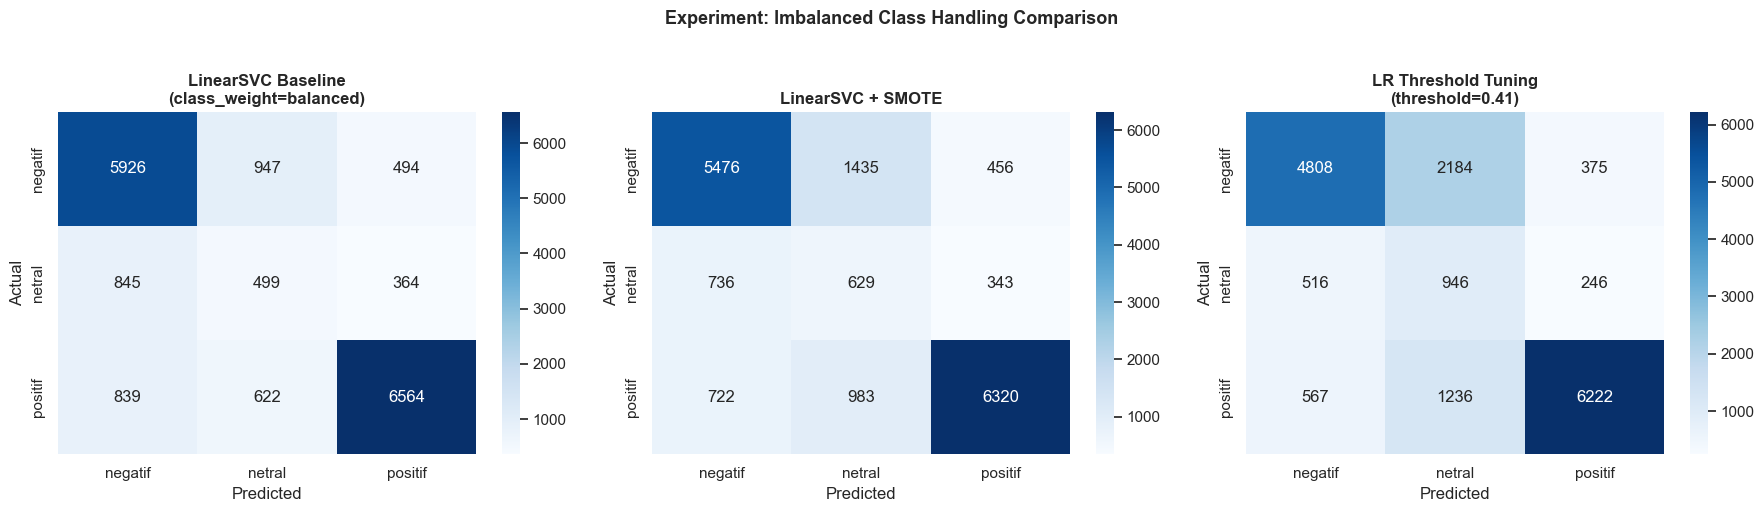

In [6]:
# Visualisasi: Comparison Confusion Matrices
labels = ['negatif', 'netral', 'positif']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title in zip(axes,
    [base_preds, smote_preds, tuned_preds],
    ['LinearSVC Baseline\n(class_weight=balanced)',
     'LinearSVC + SMOTE',
     f'LR Threshold Tuning\n(threshold={best_thresh:.2f})']):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Experiment: Imbalanced Class Handling Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## Kesimpulan Akhir Eksperimen

| Aspek | Temuan | Keputusan |
|---|---|---|
| **Cross-Validation** | Performa konsisten (std ±0.00-0.01) di 5 fold | LinearSVC dikonfirmasi sebagai model terbaik |
| **SMOTE** | Netral F1: 0.2643 → 0.2646 | Improvement minor — masalah utama adalah ambiguitas semantik bukan jumlah data |
| **Threshold Tuning** | Netral F1: 0.3096 → 0.2927 (threshold=0.50) | Trade-off dengan Weighted F1 — tidak dipakai di produksi |
| **max_features** | 5000 sudah optimal | Konfigurasi Notebook 03 dikonfirmasi |

> **Rekomendasi Final**: Model `LinearSVC` dengan konfigurasi baseline (TF-IDF `max_features=5000`, `class_weight='balanced'`) tetap menjadi pilihan terbaik untuk production. Rendahnya F1 kelas Netral (~0.26) didokumentasikan sebagai **limitasi inheren dari label proxy** dan dicatat sebagai target perbaikan menggunakan **IndoBERT** di tahap pengembangan lanjutan.
